# Fruit and Vegetable Fresh/Rotten Classification CNN.

## Tasks.
- Download, unzip and prepare dataset.
- Preprocess dataset.
- Train and test model.
- Implement Grading as set out in the case study.
- Export model.

In [50]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import random
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from wcwidth import width

### Checking if the dataset exists, if it does not then download it from custom S3 bucket and prepare it.
For simplicity the kaggle dataset was uploaded to an S3 bucket for ease-of-access.

In [51]:
DATASET_DIRECTORY = '../dataset/Fruit And Vegetable Diseases Dataset'
BATCH_SIZE = 32
IMAGE_SIZE = (244, 244)
EPOCHS = 20
RAN_SEED = 181181 # Arbitrary seed for random number generation.

# Set seeds for random number generators.
tf.random.set_seed(RAN_SEED)
np.random.seed(RAN_SEED)
random.seed(RAN_SEED)

# Checking if dataset is present, if not then download and extract.
def check_dataset():
    if not os.path.exists(DATASET_DIRECTORY):
        print('Dataset not found, checking directory...')
        if not os.path.exists('../dataset'): os.mkdir('../dataset')
        if not os.path.isfile('../dataset/archive.zip'):
            print('Downloading archive...')
            import boto3
            from botocore import UNSIGNED
            from botocore.config import Config
            bucket_name = 'aai-university-content'
            endpoint = 'https://s3.fr-par.scw.cloud'
            file_key = 'archive2.zip'
            local_file = '../dataset/archive.zip'
            s3 = boto3.client('s3',endpoint_url=endpoint,config=Config(signature_version=UNSIGNED))
            s3.download_file(bucket_name, file_key, local_file)
            print('Archive download complete.')

        print('Archive found, extracting archive...')
        from zipfile import ZipFile
        with ZipFile("../dataset/archive.zip", 'r') as zip_ref:
            zip_ref.extractall(path="../dataset")
        print('Archive extraction complete.')
        print('Removing archive...')
        os.remove('../dataset/archive.zip')
        print('Archive removed.')
    print('Dataset found.')

check_dataset()

Dataset found.


### Identify classes, images and labels from dataset.


Classes loaded: 28
Image locations loaded: 29273
Labels loaded: 29273


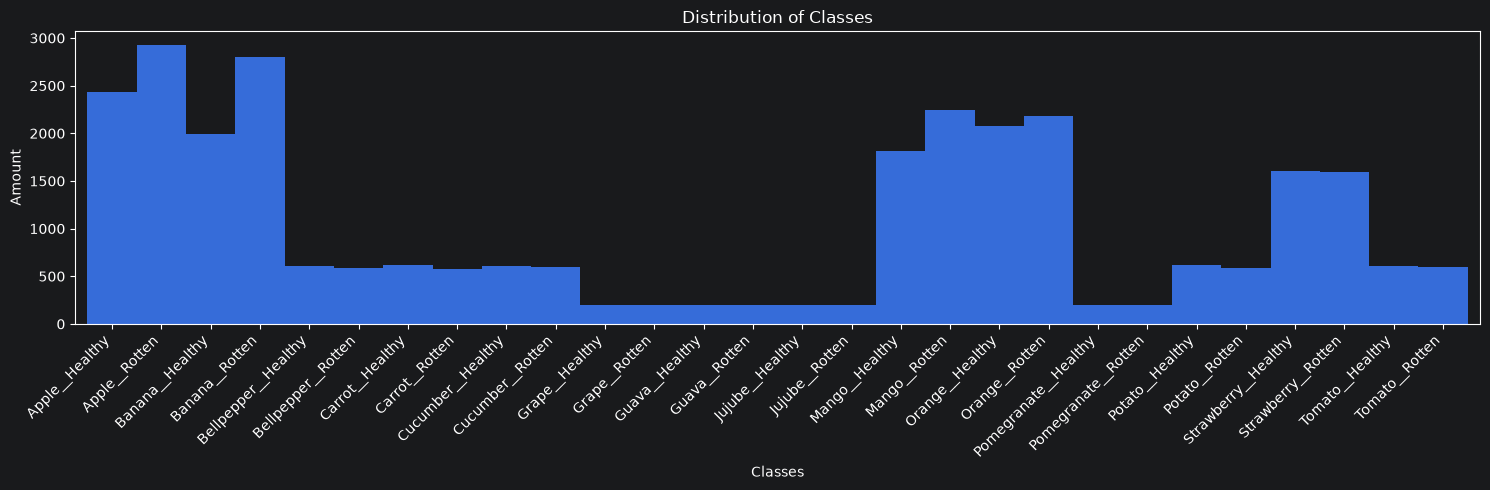

In [83]:
dataset_img_paths = []
dataset_labels = []

# Identify the class names.
dataset_classes = sorted([x for x in os.listdir(DATASET_DIRECTORY) if os.path.isdir(os.path.join(DATASET_DIRECTORY, x))])

# Iterate through files to identify images and labels.
for label, dataset_class in enumerate(dataset_classes):
    directory = os.path.join(DATASET_DIRECTORY, dataset_class)
    for file_identifier in os.listdir(directory):
        if file_identifier.lower().endswith(('.jpg', '.jpeg', '.png')):
            dataset_img_paths.append(os.path.join(directory, file_identifier))
            dataset_labels.append(label)

print("Classes loaded: " + str(len(dataset_classes)))
print("Image locations loaded: " + str(len(dataset_img_paths)))
print("Labels loaded: " + str(len(dataset_labels)))

# Create simple table for displaying the total amount of data in each class.
dataset_label_ints = pd.Series(dataset_labels).value_counts().sort_index()
dataset_distribution = pd.DataFrame({
    "Class": dataset_classes,
    "Amount": dataset_label_ints.values
})
ax = dataset_distribution.set_index('Class').plot(kind='bar', width=1, figsize=(15,5), legend=False)
plt.xticks(rotation=45, ha="right")
plt.title('Distribution of Classes')
plt.xlabel('Classes')
plt.ylabel('Amount')
plt.tight_layout()
plt.show()

### Split the data into training, validation and testing.

Using an 80/10/10 split of training, validation and testing data.

In [53]:
X_training, X_valTest, y_training, y_valTest = train_test_split(
    dataset_img_paths,
    dataset_labels,
    test_size=0.2,
    random_state=RAN_SEED
)

X_validation, X_testing, y_validation, y_testing = train_test_split(
    X_valTest,
    y_valTest,
    test_size=0.5,
    random_state=RAN_SEED
)

print(
    'Training Data:', str(len(X_training)),
    '\nValidation Data:', str(len(X_validation)),
    '\nTesting Data:', str(len(X_testing))
)

Training Data: 23418 
Validation Data: 2927 
Testing Data: 2928


### Image loading and dataset creation functions

In [54]:
def load_images(dataset_image_path, dataset_image_label):
    dataset_image = tf.io.read_file(dataset_image_path)
    dataset_image = tf.image.decode_image(dataset_image, channels=3, expand_animations=False)
    dataset_image = tf.image.resize(dataset_image, IMAGE_SIZE)
    #dataset_image = tf.image.convert_image_dtype(dataset_image, tf.float32)
    dataset_image = tf.cast(dataset_image, tf.float32) / 255.0
    return dataset_image, dataset_image_label

def create_tensorflow_dataset(dataset_image_path, dataset_image_label, train):
    tf_dataset = tf.data.Dataset.from_tensor_slices((dataset_image_path, dataset_image_label))
    tf_dataset = tf_dataset.map(load_images, num_parallel_calls=tf.data.AUTOTUNE)
    if train: tf_dataset = tf_dataset.shuffle(1000, RAN_SEED)
    tf_dataset = tf_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return tf_dataset

### Use above functions to instantiate the training, validation and testing datasets.
Also, an optional function to visualise the training data if line 18 uncommented.

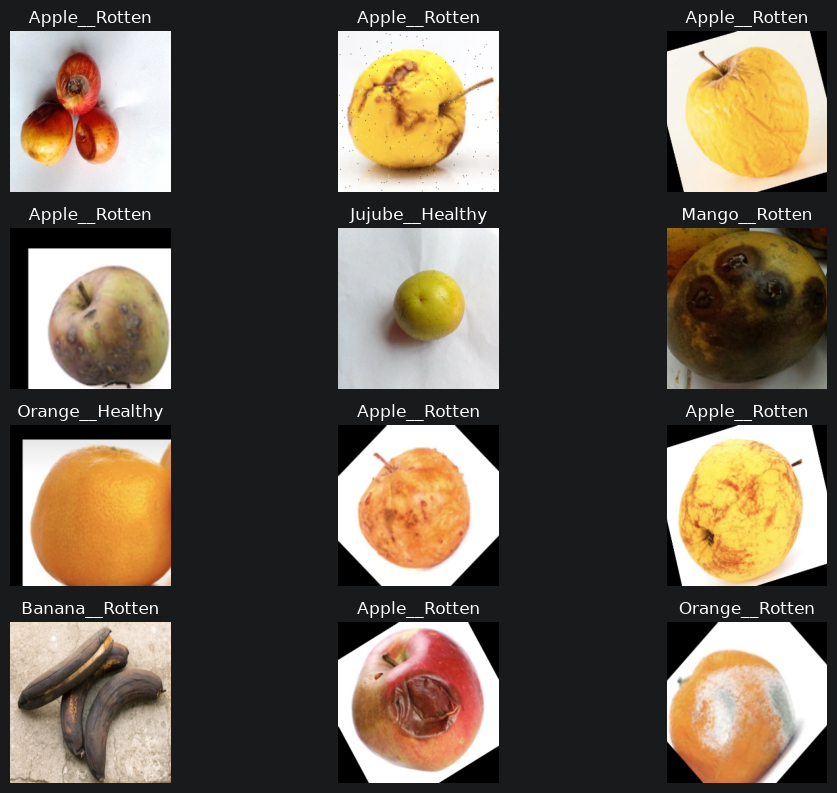

In [55]:
tf_training_dataset = create_tensorflow_dataset(X_training, y_training, True)
tf_validation_dataset = create_tensorflow_dataset(X_validation, y_validation,False)
tf_testing_dataset = create_tensorflow_dataset(X_testing, y_testing, False)

# Visualise training data
def vis_training_data():
    plt.figure(figsize=(10,10))
    for image, d_label in tf_training_dataset.take(1):
        for i in range(12):
            ax = plt.subplot(5, 3, i + 1)
            plt.imshow(image[i].numpy(), cmap='gray')
            plt.title(dataset_classes[d_label[i].numpy()])
            plt.axis('off')
    plt.tight_layout()
    plt.show()

# UNCOMMENT THIS TO RENDER VISUALISATION
vis_training_data()

### Create and Compile Keras Model

In [56]:
dataset_classes_amount = len(dataset_classes)
dataset_model_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomZoom(0.1),
        tf.keras.layers.RandomRotation(0.1),
        tf.keras.layers.RandomFlip('horizontal')
    ]
)

dataset_model = models.Sequential(
    [
        layers.Input(shape=(244, 244, 3)),
        dataset_model_augmentation,
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(dataset_classes_amount, activation='softmax')
    ]
)

dataset_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'],)
dataset_model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_12 (Sequential)      │ (None, 244, 244, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 244, 244, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 122, 122, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 122, 122, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 61, 61, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 61, 61, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 30, 30, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 15, 15, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │    14,745,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 28)             │         7,196 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,141,468 (57.76 MB)

 Trainable params: 15,141,468 (57.76 MB)

 Non-trainable params: 0 (0.00 B)

### Fit the Model

In [57]:
dataset_model_callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, verbose=0, mode='auto', restore_best_weights=True),
    ModelCheckpoint(filepath='../models/fruit_cnn.keras', monitor='val_accuracy', save_best_only=True, mode='auto', verbose=0),
]
cnn_history = dataset_model.fit(tf_training_dataset, validation_data=tf_validation_dataset, epochs=EPOCHS, callbacks=dataset_model_callbacks, shuffle=False)

# Test model using testing data.
cnn_test_loss, cnn_test_accuracy = dataset_model.evaluate(tf_testing_dataset, verbose=0)
print('CNN Testing Data Loss:', cnn_test_loss, ',\nCNN Testing Data Accuracy:', cnn_test_accuracy)


Epoch 1/20
 18/732 ━━━━━━━━━━━━━━━━━━━━ 3:52 326ms/step - accuracy: 0.1111 - loss: 3.1563

W0000 00:00:1783011123.520731 1345526 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


732/732 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - accuracy: 0.4214 - loss: 1.9467

W0000 00:00:1783011368.863734 1352910 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1783011369.139868 1352915 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


732/732 ━━━━━━━━━━━━━━━━━━━━ 255s 347ms/step - accuracy: 0.4214 - loss: 1.9467 - val_accuracy: 0.5975 - val_loss: 1.3058
Epoch 2/20
 18/732 ━━━━━━━━━━━━━━━━━━━━ 3:55 330ms/step - accuracy: 0.5295 - loss: 1.5141

...

732/732 ━━━━━━━━━━━━━━━━━━━━ 270s 367ms/step - accuracy: 0.9037 - loss: 0.3001 - val_accuracy: 0.9289 - val_loss: 0.2577
Epoch 20/20
 18/732 ━━━━━━━━━━━━━━━━━━━━ 4:06 345ms/step - accuracy: 0.9201 - loss: 0.2428

W0000 00:00:1783016137.956000 1448773 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


732/732 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step - accuracy: 0.9057 - loss: 0.2983

W0000 00:00:1783016392.296818 1458284 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1783016392.582027 1458302 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


732/732 ━━━━━━━━━━━━━━━━━━━━ 264s 359ms/step - accuracy: 0.9057 - loss: 0.2983 - val_accuracy: 0.9265 - val_loss: 0.2496
CNN Testing Data Loss: 0.22730693221092224 ,
CNN Testing Data Accuracy: 0.936133861541748


### Display accuracy, loss and classification report of model in a visual format

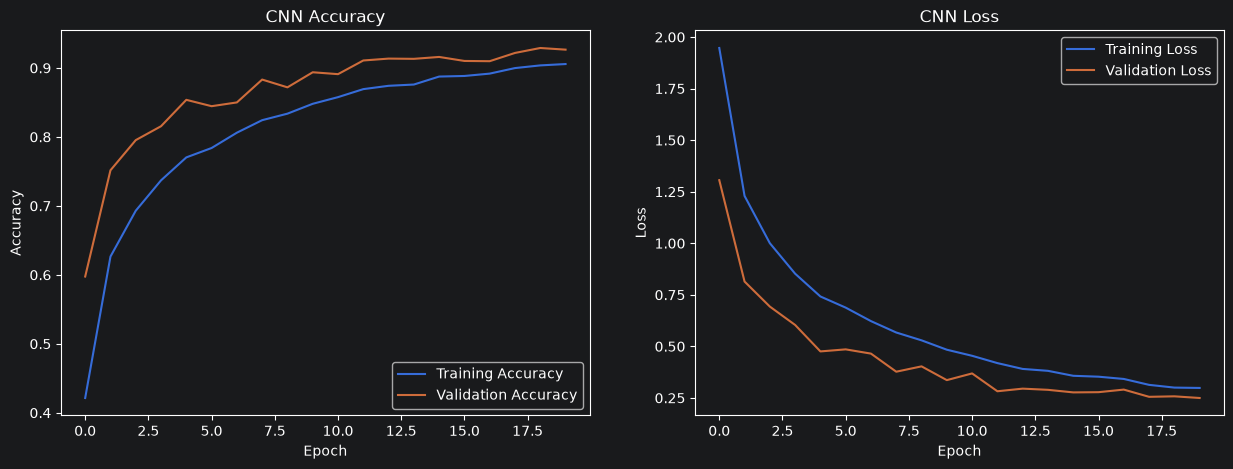

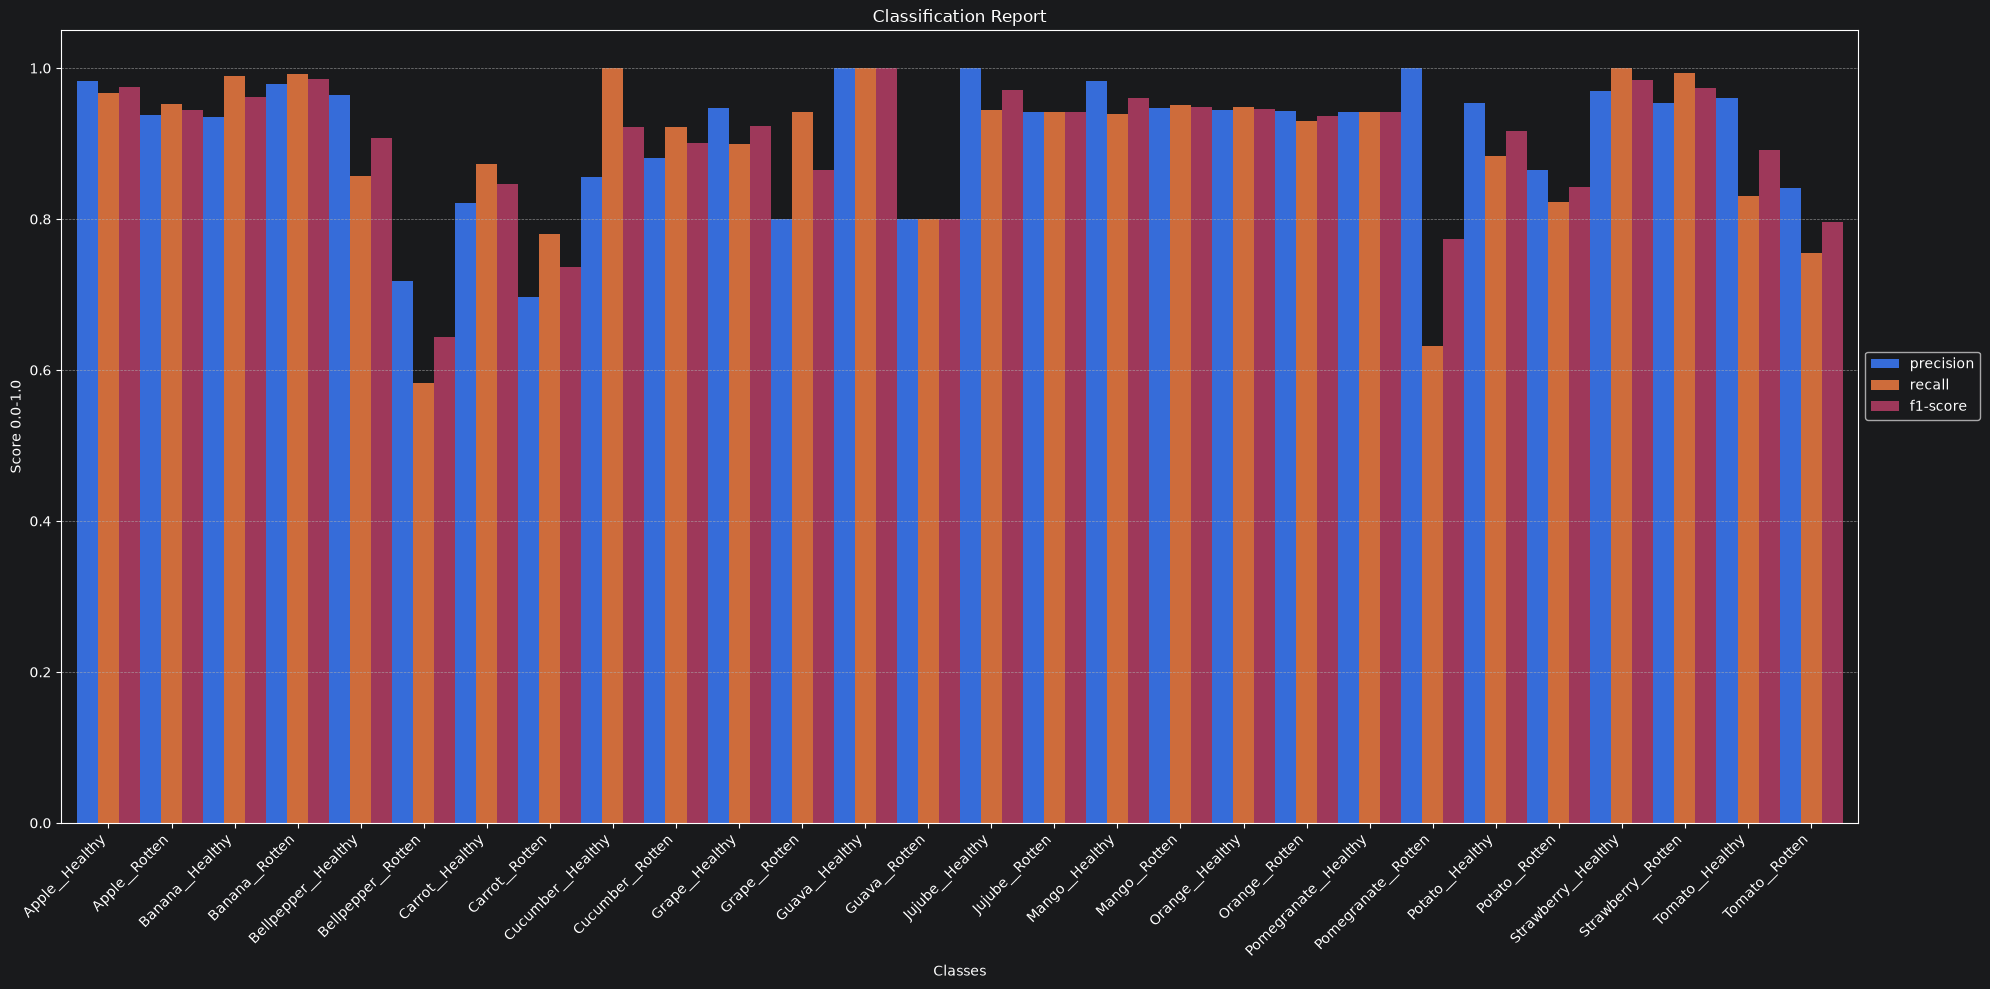

In [72]:
from sklearn.metrics import classification_report

# Get data for classification report.
y_true = []
y_predicted = []
for images, labels_batch in tf_testing_dataset:
    predicted = dataset_model.predict(images, verbose=0)
    predicted_labels = np.argmax(predicted, axis=1)

    y_true.extend(labels_batch.numpy())
    y_predicted.extend(predicted_labels)

# Model accuracy and loss figure
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.plot(cnn_history.history['accuracy'], label="Training Accuracy")
plt.plot(cnn_history.history['val_accuracy'], label="Validation Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.plot(cnn_history.history['loss'], label="Training Loss")
plt.plot(cnn_history.history['val_loss'], label="Validation Loss")
plt.legend()
plt.show()


# Classification report figure.
classification_report_dictionary = classification_report(y_true, y_predicted, target_names=dataset_classes, output_dict=True)
df = pd.DataFrame(classification_report_dictionary).iloc[:-1, :28].T

ax = df.plot(kind='bar', width=1, figsize=(20,10))
plt.title('Classification Report')
plt.xlabel('Classes')
plt.ylabel('Score 0.0-1.0')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1.05)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(loc="lower left", bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()
plt.show()

# Save model to dir.
dataset_model.save('../models/trained_fruit_cnn.keras')
